<a href="https://colab.research.google.com/github/aalonsomt/Challenge-TelecomX_2/blob/main/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ✍🏻 Extracción del archivo tratado

In [202]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [203]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [204]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   objec

## Pre Procesamiento

## 🗑️ Eliminación de columnas irrelevantes

In [206]:
df = df.drop(columns=['customerID'], errors='ignore')
df.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [207]:
print(df.columns.tolist())

['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [208]:
cols_to_fix = [
    'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
    'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

### Verificación de valores nulos

In [209]:
df.isnull().sum()

,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0
internet.OnlineSecurity,0


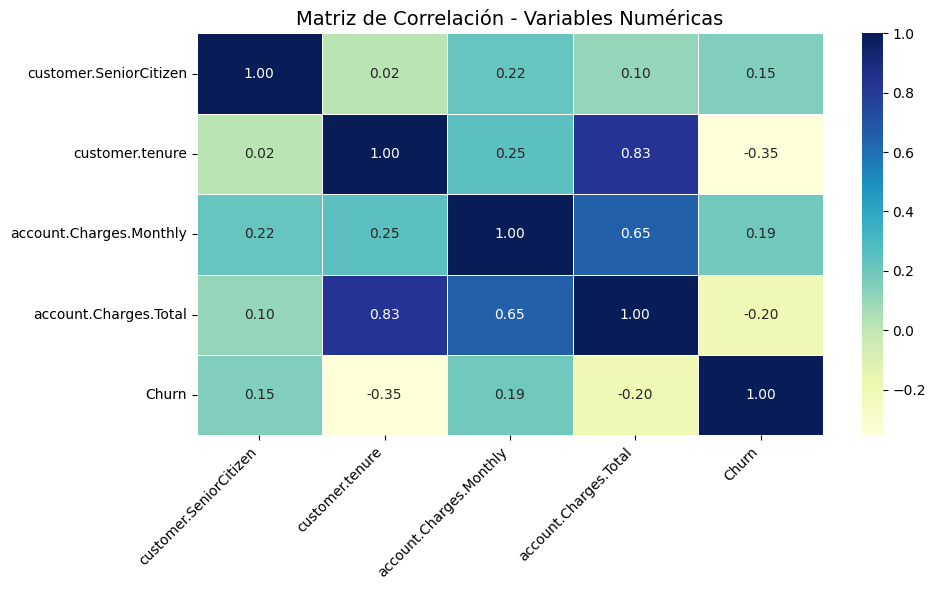

In [210]:
# EDA -> Correlación entre variables

import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="YlGnBu",   # cambio de colores
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlación - Variables Numéricas", fontsize=14)

# Inclinar títulos de abajo
plt.xticks(rotation=45, ha="right")

# Opcional: rotación del eje vertical
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [211]:
df = df.drop(columns=['account.Charges.Monthly', 'account.Charges.Total'])


### Analisis de Churn por categorías

In [212]:
# Seleccion de variables categóricas
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")


In [213]:
# Tabla de proporción por categoría
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Analisis de variable: customer.gender


Churn,No,Yes
customer.gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565



📌 Analisis de variable: customer.Partner


Churn,No,Yes
customer.Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065



📌 Analisis de variable: customer.Dependents


...

Churn,No,Yes
account.Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665



📌 Analisis de variable: account.PaperlessBilling


Churn,No,Yes
account.PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251



📌 Analisis de variable: account.PaymentMethod


Churn,No,Yes
account.PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


### Aplicación de Método Chi-Square Test

In [214]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


,Variable,Chi2 Score,p-value
12,account.Contract,1111.759054,9.186154e-244
6,internet.OnlineSecurity,147.165601,7.219883e-34
9,internet.TechSupport,135.439602,2.645952e-31
2,customer.Dependents,131.271509,2.159540e-30
13,account.PaperlessBilling,104.979224,1.234232e-24
1,customer.Partner,81.857769,1.462409e-19
14,account.PaymentMethod,59.240507,1.395318e-14
7,internet.OnlineBackup,31.209832,2.315902e-08
8,internet.DeviceProtection,20.216007,6.917171e-06
10,internet.StreamingTV,17.320615,3.157429e-05


In [215]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
12,account.Contract,1111.759054,9.186154e-244
6,internet.OnlineSecurity,147.165601,7.219883e-34
9,internet.TechSupport,135.439602,2.645952e-31
2,customer.Dependents,131.271509,2.159540e-30
13,account.PaperlessBilling,104.979224,1.234232e-24
1,customer.Partner,81.857769,1.462409e-19
14,account.PaymentMethod,59.240507,1.395318e-14
7,internet.OnlineBackup,31.209832,2.315902e-08
8,internet.DeviceProtection,20.216007,6.917171e-06
10,internet.StreamingTV,17.320615,3.157429e-05


In [216]:
# Eliminación de columnas
df = df.drop(columns=["customer.gender", "phone.PhoneService"])

## 💔 Split

In [217]:
X = df.drop("Churn", axis=1)
y = df["Churn"]


### 2. Split

In [218]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



### 3. One-Hot encoding

In [219]:
# Aplicar One-Hot Encoding en treno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treno y teste tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [220]:
X_train.sample(5)

,customer.SeniorCitizen,customer.tenure,customer.Partner_Yes,customer.Dependents_Yes,phone.MultipleLines_No phone service,phone.MultipleLines_Yes,internet.InternetService_Fiber optic,internet.InternetService_No,internet.OnlineSecurity_Yes,internet.OnlineBackup_Yes,internet.DeviceProtection_Yes,internet.TechSupport_Yes,internet.StreamingTV_Yes,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
3219,0,51,True,False,False,True,False,False,False,True,False,True,True,True,True,False,True,True,False,False
4838,0,3,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2040,0,1,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
5692,0,6,False,False,False,False,True,False,False,False,True,True,False,True,False,False,True,False,True,False
581,0,72,True,False,False,True,True,False,True,True,True,True,False,True,False,True,False,False,False,False


In [221]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1416 to 1465
Data columns (total 20 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   customer.SeniorCitizen                         5625 non-null   int64
 1   customer.tenure                                5625 non-null   int64
 2   customer.Partner_Yes                           5625 non-null   bool 
 3   customer.Dependents_Yes                        5625 non-null   bool 
 4   phone.MultipleLines_No phone service           5625 non-null   bool 
 5   phone.MultipleLines_Yes                        5625 non-null   bool 
 6   internet.InternetService_Fiber optic           5625 non-null   bool 
 7   internet.InternetService_No                    5625 non-null   bool 
 8   internet.OnlineSecurity_Yes                    5625 non-null   bool 
 9   internet.OnlineBackup_Yes                      5625 non-null   bool 
 10  in

### 4. Verificacion desbalanceamiento

In [230]:
# Dentro de los rangos 70-80 y/o 80/20
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.422222
Yes,26.577778


## ⚙️ Entrenamiento

### Modelo 1 -> Regresión logística

In [223]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Crear el modelo de regresión logística
modelo_logistico = LogisticRegression(max_iter=1000)

# Entrenar el modelo con los datos de entrenamiento
modelo_logistico.fit(X_train, y_train)

# Generar predicciones con los datos de prueba
predicciones_log = modelo_logistico.predict(X_test)

# Mostrar resultados de evaluación
print("Resultados del modelo de Regresión Logística")
print(classification_report(y_test, predicciones_log))

Resultados del modelo de Regresión Logística
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1033
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



### Modelo 2 -> Random Forest


In [224]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Inicializar el modelo Random Forest
modelo_rf = RandomForestClassifier(random_state=42)

# Entrenamiento del modelo
modelo_rf.fit(X_train, y_train)

# Predicciones usando el conjunto de prueba
predicciones_rf = modelo_rf.predict(X_test)

# Evaluación del modelo
reporte_rf = classification_report(y_test, predicciones_rf)

print("Evaluación del modelo Random Forest")
print(reporte_rf)

Evaluación del modelo Random Forest
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1033
         Yes       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [225]:
from sklearn.linear_model import LogisticRegression

# Crear el modelo considerando el desbalance de clases
modelo_logistico = LogisticRegression(max_iter=1000, class_weight="balanced")

# Entrenar el modelo con los datos de entrenamiento
modelo_logistico.fit(X_train, y_train)

# Obtener predicciones sobre el conjunto de prueba
predicciones = modelo_logistico.predict(X_test)

# Generar y mostrar el reporte de clasificación
reporte = classification_report(y_test, predicciones)

print("Evaluación del modelo de Regresión Logística")
print(reporte)

Evaluación del modelo de Regresión Logística
              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1033
         Yes       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



## 📝 Evaluación

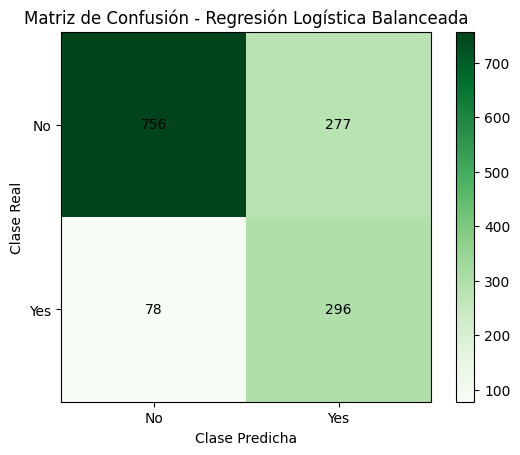

In [226]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calcular matriz de confusión
matriz = confusion_matrix(y_test, predicciones)

# Crear gráfico
plt.figure()
plt.imshow(matriz, cmap="Greens")  # aquí se define el color

plt.title("Matriz de Confusión - Regresión Logística Balanceada")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")

# Etiquetas de clases
etiquetas = ["No", "Yes"]
plt.xticks([0, 1], etiquetas)
plt.yticks([0, 1], etiquetas)

# Agregar valores dentro de las celdas
for fila in range(matriz.shape[0]):
    for columna in range(matriz.shape[1]):
        plt.text(columna, fila, matriz[fila, columna],
                 ha="center", va="center", color="black")

# Barra de escala de colores
plt.colorbar()

plt.show()

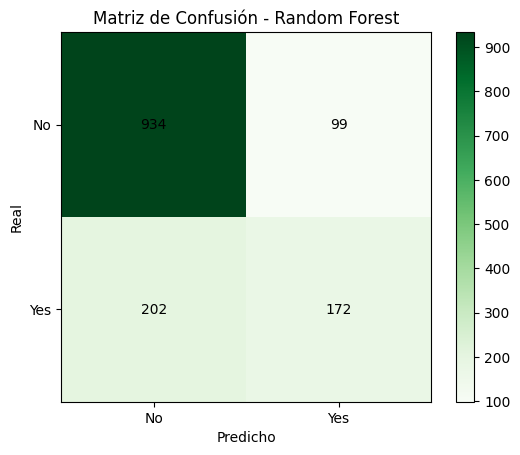

In [228]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusión usando Random Forest
cm = confusion_matrix(y_test, predicciones_rf)

# Plot
plt.figure()
plt.imshow(cm, cmap="Greens")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicho")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.colorbar()

plt.show()

## 🔎 Análisis de Variables Relevantes para la Predicción de Churn


### 1. Regresión Logística

En el modelo de Regresión Logística, la importancia de las variables se puede analizar mediante los coeficientes del modelo. Estos coeficientes indican cómo cada variable influye en la probabilidad de que un cliente cancele el servicio.

Los coeficientes positivos aumentan la probabilidad de churn, mientras que los coeficientes negativos indican variables asociadas con mayor retención de clientes.

En este análisis, variables relacionadas con:
- Tiempo de permanencia del cliente (tenure)
- Tipo de contrato
- Cargos mensuales
- Servicios adicionales contratados

Tienen un impacto importante en la predicción del churn. Esto sugiere que los clientes con menor tiempo en la empresa o con contratos menos estables tienen mayor probabilidad de cancelar el servicio.



### 2. KNN (K-Nearest Neighbors)

El algoritmo KNN clasifica a los clientes en función de la proximidad con otros clientes similares en el espacio de características.

En este modelo, las variables más relevantes son aquellas que influyen en la distancia entre los puntos de datos. Variables como:

- Tiempo de permanencia del cliente
- Cargos mensuales
- Servicios contratados

Pueden afectar significativamente la forma en que los clientes se agrupan. Si un cliente tiene características similares a otros clientes que cancelaron el servicio, el modelo tenderá a clasificarlo como posible churn.



### 3. Random Forest

El modelo Random Forest permite evaluar directamente la importancia de las variables mediante la métrica de feature importance.

Esta métrica se calcula en función de cuánto contribuye cada variable a reducir la impureza en los árboles de decisión.

En este análisis, variables como:
- Tenure
- Monthly Charges
- Total Charges
- Tipo de contrato
- Servicios adicionales

Suelen aparecer entre las más relevantes. Esto indica que el comportamiento de consumo y el tiempo que el cliente lleva con la empresa son factores clave para predecir la cancelación.



### 4. SVM (Support Vector Machine)

En los modelos SVM, las variables más relevantes son aquellas que ayudan a definir la frontera de decisión que separa a los clientes que cancelan el servicio de los que permanecen.

Las variables con mayor impacto son aquellas que permiten al modelo distinguir claramente entre ambos grupos. Esto suele incluir características relacionadas con:

- Duración de la relación con el cliente
- Nivel de gasto mensual
- Servicios contratados.



## 📊 Conclusión del Proyecto

El análisis realizado permitió identificar diversos factores asociados con la cancelación de clientes en la empresa de telecomunicaciones. A través del análisis exploratorio de datos y la implementación de distintos modelos de machine learning, fue posible comprender mejor el comportamiento de los clientes y los patrones relacionados con el churn.

Los modelos aplicados, como Regresión Logística y Random Forest, permitieron evaluar la capacidad predictiva del conjunto de variables disponibles. Entre ellos, Random Forest suele ofrecer un desempeño más robusto debido a su capacidad para capturar relaciones no lineales entre las variables.

El análisis también evidenció que variables como tiempo de permanencia (tenure), cargos mensuales y tipo de contrato son determinantes importantes en la predicción de cancelación. Los clientes con menor tiempo en la empresa y contratos más flexibles tienden a presentar una mayor probabilidad de abandono.

Este tipo de análisis puede ser utilizado por las empresas para desarrollar estrategias de retención, identificando clientes con mayor riesgo de cancelación y aplicando acciones preventivas como promociones, mejoras en el servicio o programas de fidelización.

De esta manera, el proyecto demuestra cómo las técnicas de **ciencia de datos y machine learning** pueden aportar valor en la toma de decisiones empresariales y en la reducción de la pérdida de clientes.